In [1]:
import pennylane as qml 
import torch
import pennylane.numpy as np 
import pandas as pd

In [2]:
df = pd.read_csv('spx_d.csv')
df['x'] = range(1, len(df) + 1)
data = df['Zamkniecie']

In [3]:
from sklearn.preprocessing import MinMaxScaler
# Initialize the scaler to scale between -1 and 1
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit and transform the data
data_scaled = scaler.fit_transform(data.values.reshape(-1,1))

# Convert back to DataFrame if needed
data_scaled_df = pd.DataFrame(data_scaled, columns=['Zamkniecie_scaled'])

In [4]:
df['Zamkniecie_scaled'] = data_scaled_df

In [5]:
dane_y = torch.from_numpy(df['Zamkniecie_scaled'].values).view(-1,1).to(torch.float)
dane_y = dane_y[-300:]
dane_y_q = torch.pi * dane_y
dane_x = torch.from_numpy(df['x'].values).view(-1,1).to(torch.float)
dane_x = dane_x[-300:]


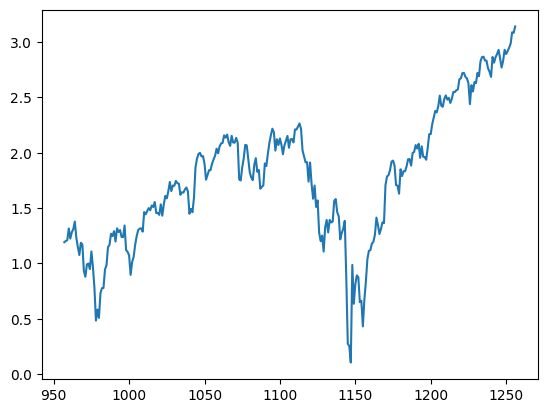

In [6]:
import matplotlib.pyplot as plt
plt.plot(dane_x, dane_y_q)

In [7]:
import torch
import torch.nn as nn
from torch.optim import Optimizer
from typing import Callable, Optional
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Mean squared error loss with type annotations and better numerical stability
def mse(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    return torch.mean(torch.square(y_true - y_pred))

# Training loop with type annotations and structure
def train(
    X: torch.Tensor,
    Y: torch.Tensor,
    x_true: torch.Tensor,
    y_true: torch.Tensor,
    model: nn.Module,
    optimizer: Optimizer,
    iterations: int,
    lossfn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    callback: Optional[Callable[[nn.Module, torch.Tensor], None]] = None
) -> None:
    """
    Trains the given model on input X and target Y using the specified optimizer and loss function.
    Optionally, a callback function can be provided for monitoring progress.
    """
    for i in range(iterations):
        optimizer.zero_grad()
        prediction = model(X)
        loss = lossfn(Y, prediction)
        loss.backward()
        optimizer.step()

        if callback is not None:
            callback(model, loss, x_true, y_true)

# Loss tracking list
losses: list[float] = []

# Callback function for visualizing training progress
def callback(model: nn.Module, loss: torch.Tensor, x, y) -> None:
    losses.append(loss.item())
    
    #x = torch.linspace(0, 10, 500).view(-1, 1)
    prediction = model(x).detach()

    clear_output(wait=True)

    # Plot predictions vs. true sine function
    plt.figure(figsize=(6, 2.5))
    plt.plot(x[:, 0], y[:, 0], label="Exact solution", color="tab:grey", alpha=0.6)
    plt.plot(x[:, 0], prediction[:, 0], label="Model prediction", color="tab:green")
    plt.title(f"Training Step {len(losses)}")
    plt.legend()
    plt.show()

    # Plot loss curve
    plt.figure(figsize=(6, 2.5))
    plt.title("Loss Function Over Time")
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

In [8]:
import pennylane as qml

n_qubits = 5
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

n_layers = 5

weight_shapes = {"weights": (n_layers, n_qubits, 3)}

qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)

In [9]:
class QN(torch.nn.Module):
    '''Classical -> Quantum -> Classical'''

    def __init__(self, n_input: int, n_output: int, quanutm_layer):
        super().__init__()

        self.layers = torch.nn.Sequential(
            torch.nn.Linear(n_input, n_qubits),
            quanutm_layer,
            torch.nn.Linear(n_qubits, n_output)
        )
        

    def forward(self, x):
        return  self.layers(x)

In [12]:
reg_qmodel = QN(1, 1, qlayer)
print(reg_qmodel)

QN(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=5, bias=True)
    (1): <Quantum Torch Layer: func=qnode>
    (2): Linear(in_features=5, out_features=1, bias=True)
  )
)


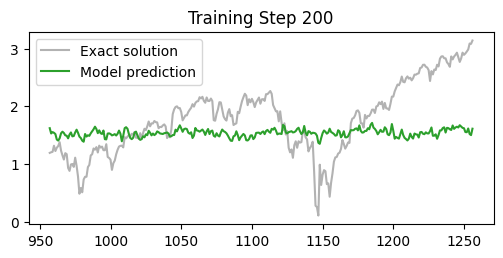

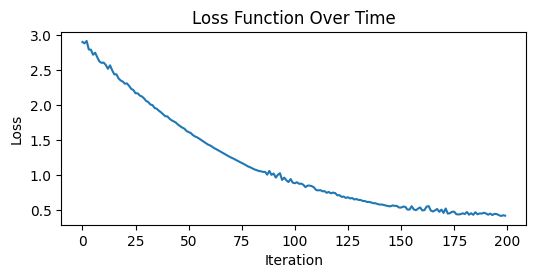

In [13]:
from IPython.display import clear_output 

learning_rate=1e-2
optimiser = torch.optim.Adam(reg_qmodel.parameters(), lr=learning_rate)

train(dane_x, dane_y_q, dane_x, dane_y_q, reg_qmodel, optimiser, 200, mse, callback)